### Importar librerias y configuracion general.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy as sa
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración
DIRECT_BASE = "C:/Proyectos/Power BI - Logística/Datos generados/"
SERVER = "LAPTOP-OFP910OT"
DATABASE = "Surcomotor_DB"

# Lista de todas las tablas
TABLAS_HECHOS = ["tabla_ventas", "tabla_compras", "tabla_stock_inventario"]
TABLAS_MAESTRAS = ["tabla_productos", "tabla_almacenes", "tabla_clientes"]

# Reporte global
reporte_errores = []

# Configurar gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")


### Carga de Tablas y Funciones Auxiliares

In [ ]:
def cargar_maestras():
    """Carga las tablas maestras desde CSV."""
    productos = pd.read_csv(os.path.join(DIRECT_BASE, "tabla_productos.csv"), encoding='utf-8-sig')
    almacenes = pd.read_csv(os.path.join(DIRECT_BASE, "tabla_almacenes.csv"), encoding='utf-8-sig')
    clientes = pd.read_csv(os.path.join(DIRECT_BASE, "tabla_clientes.csv"), encoding='utf-8-sig')
    return productos, almacenes, clientes

def es_vehiculo(desc_producto, productos_df):
    """Determina si un producto es vehículo según su tipo en tabla_productos."""
    desc = str(desc_producto).upper()
    prod_info = productos_df[productos_df["DESCRIPCIÓN"].str.upper() == desc]
    if not prod_info.empty:
        return prod_info.iloc[0]["TIPO"] in ["AUTOS", "CAMIONETAS"]
    return False  # por defecto

def validar_producto_existente(df, productos_df, col_prod="Producto", nombre_tabla=""):
    """Elimina filas con producto no registrado en tabla_productos."""
    validos = set(productos_df["DESCRIPCIÓN"].str.upper())
    mascara = df[col_prod].str.upper().isin(validos)
    eliminados = len(df) - mascara.sum()
    if eliminados > 0:
        reporte_errores.append(f"{nombre_tabla}: se eliminaron {eliminados} filas con producto no existente.")
    return df[mascara].copy()

def validar_stock_ventas(ventas_df, stock_df):
    """
    Verifica que en la fecha de venta existiera stock suficiente según el último control de inventario.
    stock_df debe tener columnas: Fecha, Almacen, Producto, Cantidad_Stock.
    """
    # Asegurar formato datetime
    stock_df = stock_df.copy()
    ventas_df = ventas_df.copy()
    stock_df["Fecha"] = pd.to_datetime(stock_df["Fecha"])
    ventas_df["Fecha"] = pd.to_datetime(ventas_df["Fecha"])
    
    stock_df = stock_df.sort_values("Fecha")
    ventas_validas = []
    
    for idx, venta in ventas_df.iterrows():
        fecha_venta = venta["Fecha"]
        almacen = venta["Almacen"]
        producto = venta["Producto"]
        cantidad = venta["Cantidad_Vendida"]
        
        # Buscar el control de stock más reciente antes o igual a la fecha de venta
        mask = (stock_df["Almacen"] == almacen) & (stock_df["Producto"] == producto) & (stock_df["Fecha"] <= fecha_venta)
        stock_previo = stock_df[mask]
        if stock_previo.empty:
            reporte_errores.append(f"Venta {venta['id_venta']}: sin control de stock previo, se elimina.")
            continue
        ultimo_stock = stock_previo.iloc[-1]["Cantidad_Stock"]
        if ultimo_stock >= cantidad:
            ventas_validas.append(venta)
        else:
            reporte_errores.append(f"Venta {venta['id_venta']}: stock insuficiente ({ultimo_stock} < {cantidad}) el {fecha_venta.date()}.")
    
    return pd.DataFrame(ventas_validas)


### Limpieza de Datos

In [10]:
def limpiar_tabla_hechos(df, nombre_tabla, productos_df, stock_df=None):
    """
    Limpieza completa:
    - Duplicados exactos
    - Eliminar negativos en columnas relevantes
    - Validar existencia de productos
    - Para ventas: validar stock
    - Outliers numéricos: por año, si hay >3 con |z|>4.5 se eliminan; si ≤3 se regresan a la media.
    """
    df = df.copy()
    
    # 1. Duplicados
    antes = len(df)
    df = df.drop_duplicates()
    if antes - len(df) > 0:
        reporte_errores.append(f"{nombre_tabla}: {antes - len(df)} duplicados eliminados.")
    
    # 2. Columnas que deben ser positivas
    positivas = {
        "tabla_ventas": ["Cantidad_Vendida", "Precio_Venta", "Monto_Venta"],
        "tabla_compras": ["Cantidad", "Precio_Compra", "Monto"],
        "tabla_stock_inventario": ["Cantidad_Stock"]
    }.get(nombre_tabla, [])
    
    for col in positivas:
        if col in df.columns:
            neg = df[df[col] < 0]
            if len(neg) > 0:
                reporte_errores.append(f"{nombre_tabla}: {len(neg)} filas con {col} negativo eliminadas.")
                df = df[df[col] >= 0]
    
    # 3. Validar producto existente
    if "Producto" in df.columns:
        df = validar_producto_existente(df, productos_df, "Producto", nombre_tabla)
    
    # 4. Validar stock (solo ventas)
    if nombre_tabla == "tabla_ventas" and stock_df is not None:
        df = validar_stock_ventas(df, stock_df)
    
    # 5. Outliers numéricos por año
    if "Fecha" in df.columns:
        df["Año"] = pd.to_datetime(df["Fecha"]).dt.year
    else:
        df["Año"] = 0  # agrupar todo
    
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    id_cols = [c for c in num_cols if "id" in c.lower()]
    num_cols = [c for c in num_cols if c not in id_cols and c != "Año"]
    
    for col in num_cols:
        nuevos_valores = []
        for año, grupo in df.groupby("Año"):
            mu = grupo[col].mean()
            sigma = grupo[col].std()
            if sigma == 0:
                nuevos_valores.extend(grupo[col].values)
                continue
            z = (grupo[col] - mu).abs() / sigma
            n_outliers = (z > 4.5).sum()
            if n_outliers <= 3:
                # Regresión a la media
                grupo.loc[z > 4.5, col] = mu
            else:
                # Eliminar filas con |z| > 4.5
                grupo = grupo[z <= 4.5]
                reporte_errores.append(f"{nombre_tabla}: se eliminaron {n_outliers} filas por outliers en {col} año {año}.")
            nuevos_valores.extend(grupo[col].values)
        # Reasignar (si hubo eliminaciones, la cantidad de filas cambia, por eso usamos el índice)
        df = df.iloc[:len(nuevos_valores)].copy()
        df[col] = nuevos_valores
    
    if "Año" in df.columns:
        df = df.drop(columns=["Año"])
    
    return df


### Análisis Exploratorio de Datos

In [13]:
def eda_completa(df, nombre_tabla):
    """Análisis exploratorio con gráficos (compatible con pandas >=2.2)."""
    print(f"\n{'='*80}")
    print(f"ANÁLISIS EXPLORATORIO: {nombre_tabla.upper()}")
    print(f"{'='*80}")
    print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nValores nulos:")
    print(df.isnull().sum())
    
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if num_cols:
        print("\nEstadísticas descriptivas:")
        display(df[num_cols].describe())
    
    # Análisis univariado
    for col in df.columns:
        if col in ['id_venta', 'id_compra', 'ID_Producto']:
            continue
        plt.figure(figsize=(12, 4))
        if pd.api.types.is_numeric_dtype(df[col]):
            plt.subplot(1,2,1)
            sns.histplot(df[col], kde=True)
            plt.title(f'Distribución de {col}')
            plt.subplot(1,2,2)
            sns.boxplot(y=df[col])
            plt.title(f'Boxplot de {col}')
        else:
            top = df[col].value_counts().head(10)
            sns.barplot(x=top.values, y=top.index)
            plt.title(f'Top 10 categorías de {col}')
        plt.tight_layout()
        plt.show()
    
    # Correlaciones
    if len(num_cols) > 1:
        plt.figure(figsize=(10, 8))
        sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
        plt.title(f'Matriz de correlación - {nombre_tabla}')
        plt.show()
    
    # Series temporales (si existe fecha) - CORREGIDO: 'ME' en lugar de 'M'
    if 'Fecha' in df.columns:
        df_temp = df.copy()
        df_temp['Fecha'] = pd.to_datetime(df_temp['Fecha'])
        df_temp.set_index('Fecha', inplace=True)
        if 'Monto' in df_temp.columns or 'Monto_Venta' in df_temp.columns:
            col_monto = 'Monto' if 'Monto' in df_temp.columns else 'Monto_Venta'
            plt.figure(figsize=(12,4))
            # 👇 Cambio clave aquí: 'ME' en lugar de 'M'
            df_temp.resample('ME')[col_monto].sum().plot()
            plt.title('Evolución mensual del monto total')
            plt.show()
        df_temp.reset_index(inplace=True)
    
    # Análisis por almacén
    if 'Almacen' in df.columns:
        col_monto = next((c for c in ['Monto', 'Monto_Venta'] if c in df.columns), None)
        if col_monto:
            plt.figure(figsize=(10,5))
            sns.barplot(data=df, x='Almacen', y=col_monto, estimator=sum, errorbar=None)
            plt.title(f'Suma de {col_monto} por almacén')
            plt.show()
    
    # Top productos por monto
    if 'Producto' in df.columns and 'Monto_Venta' in df.columns:
        top = df.groupby('Producto')['Monto_Venta'].sum().nlargest(10).reset_index()
        plt.figure(figsize=(12,6))
        sns.barplot(data=top, x='Monto_Venta', y='Producto')
        plt.title('Top 10 productos por monto de venta')
        plt.show()
        

### Ejecución y Carga de Datos a SQL Server


Procesando tabla_ventas... (4086 registros originales)
Después de limpieza: 84 registros

ANÁLISIS EXPLORATORIO: TABLA_VENTAS
Dimensiones: 84 filas, 9 columnas

Tipos de datos:
id_venta              int64
Fecha                   str
Cliente                 str
Almacen                 str
Producto                str
Cantidad_Vendida      int64
Precio_Venta        float64
Monto_Venta         float64
Vendedor                str
dtype: object

Valores nulos:
id_venta            0
Fecha               0
Cliente             0
Almacen             0
Producto            0
Cantidad_Vendida    0
Precio_Venta        0
Monto_Venta         0
Vendedor            0
dtype: int64

Estadísticas descriptivas:


,id_venta,Cantidad_Vendida,Precio_Venta,Monto_Venta
count,84.000000,84.000000,84.000000,84.000000
mean,1830.571429,1.642857,70.237500,117.419524
std,1519.756134,0.754790,11.815715,62.243682
min,100.000000,1.000000,51.080000,51.080000
25%,388.750000,1.000000,60.410000,68.882500
50%,1200.500000,1.000000,71.350000,91.660000
75%,3546.250000,2.000000,78.400000,154.122500
max,4086.000000,4.000000,91.660000,313.600000


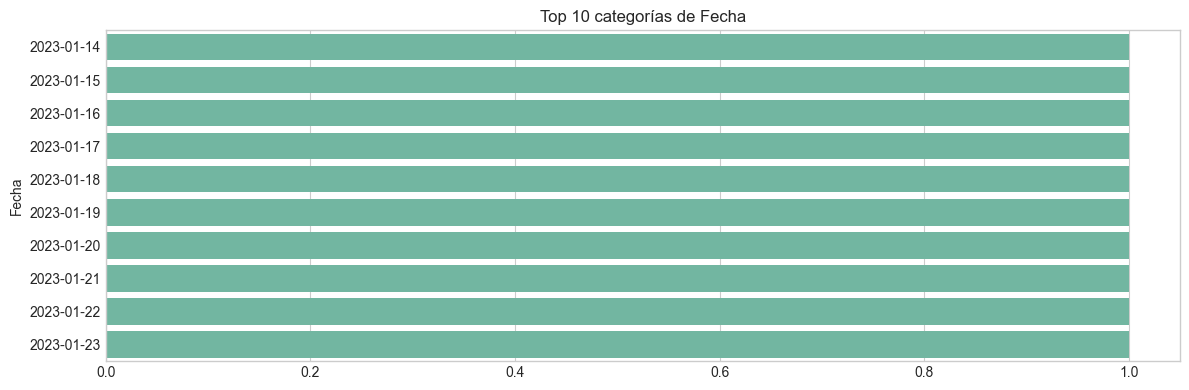

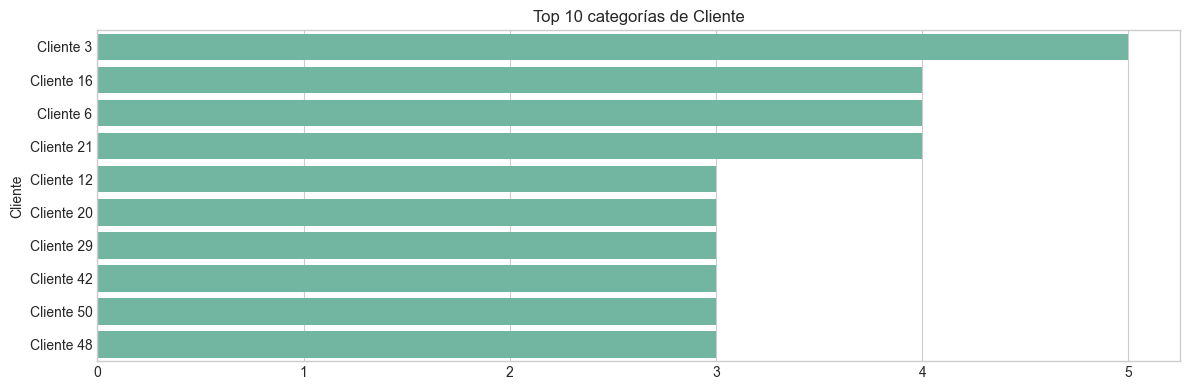

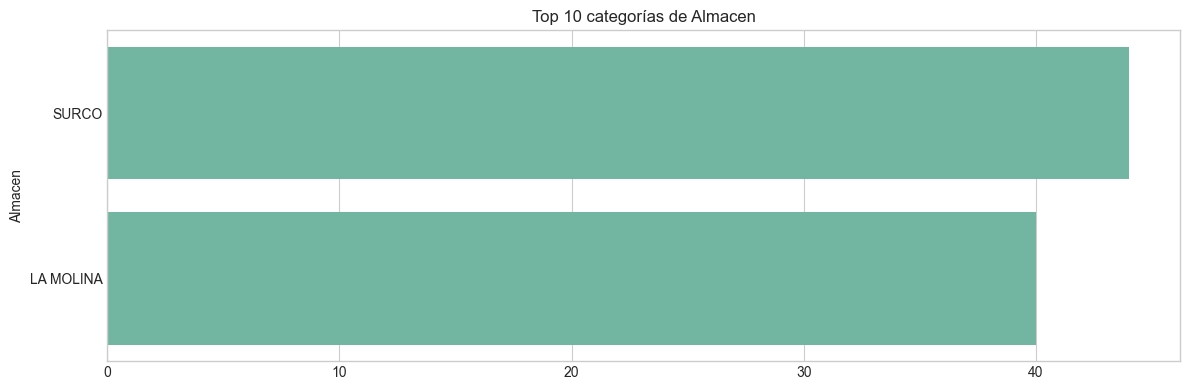

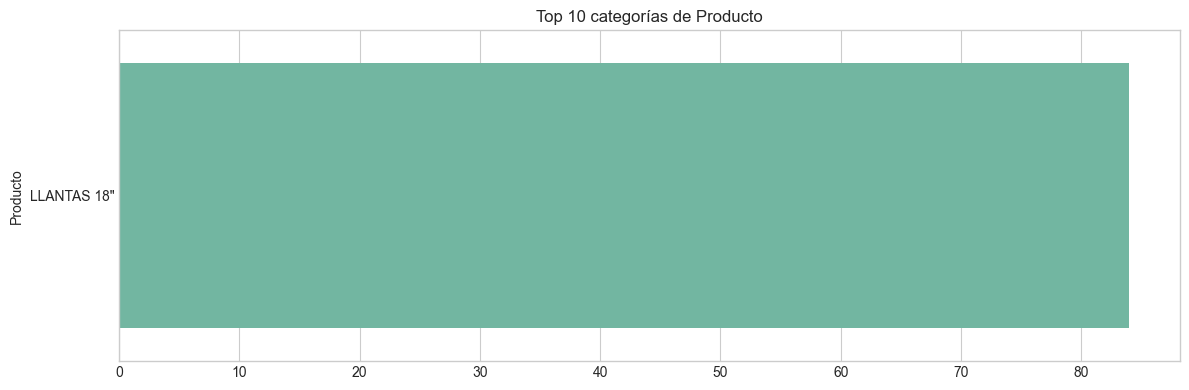

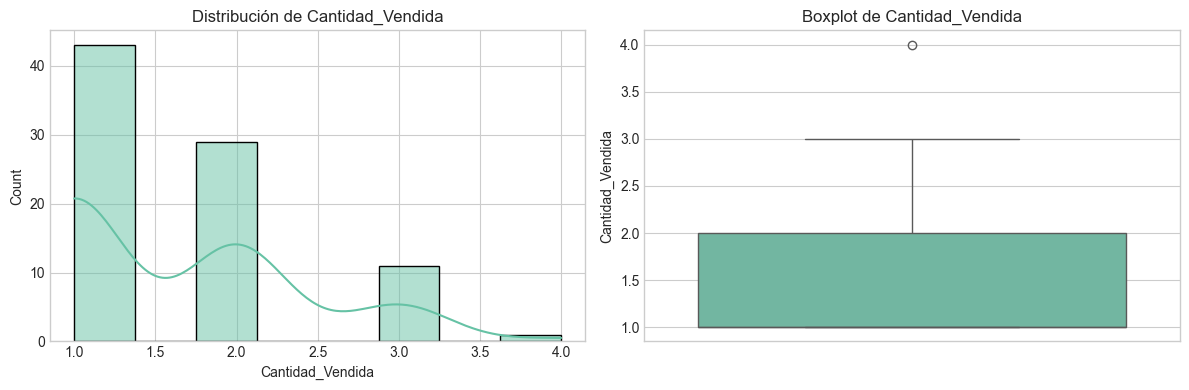

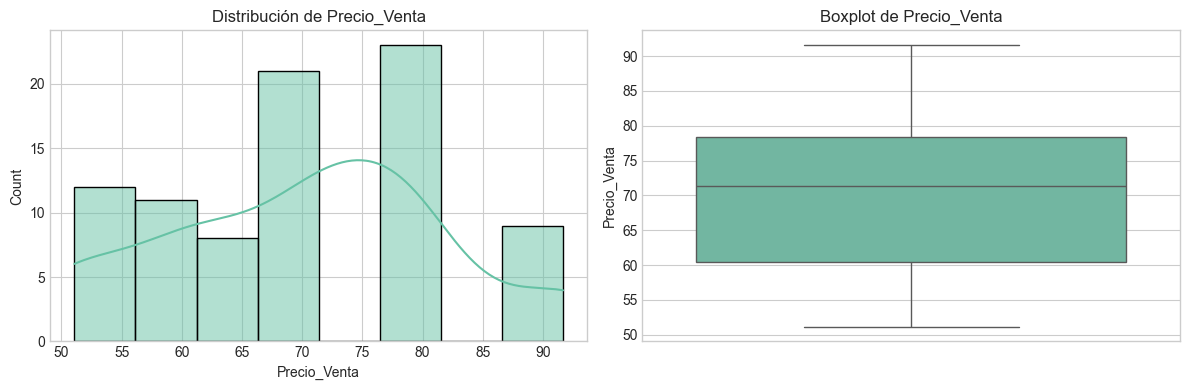

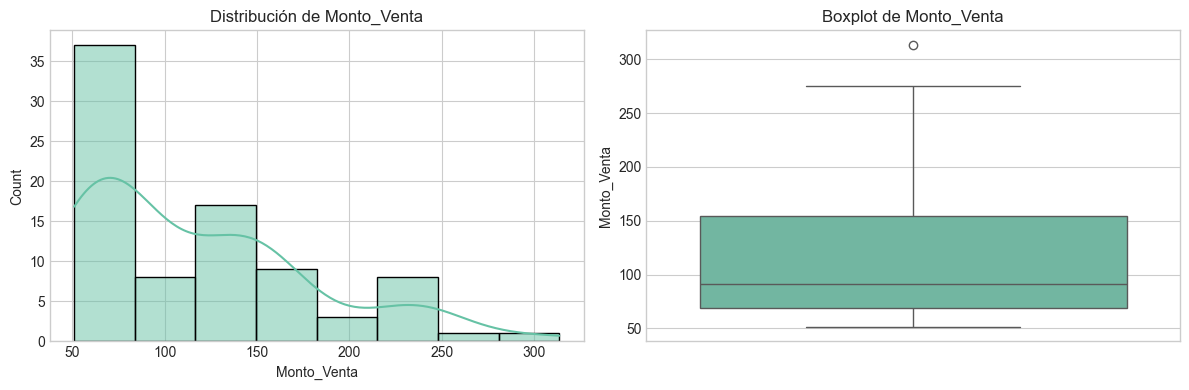

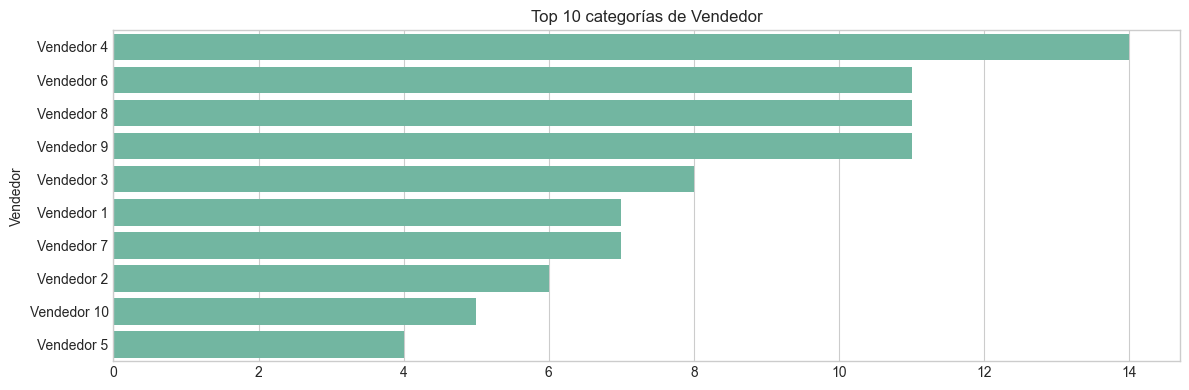

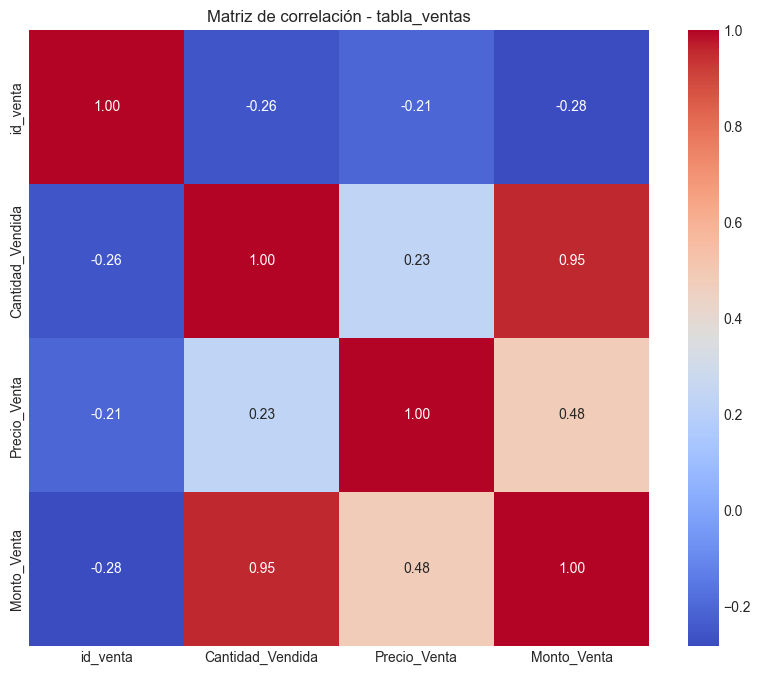

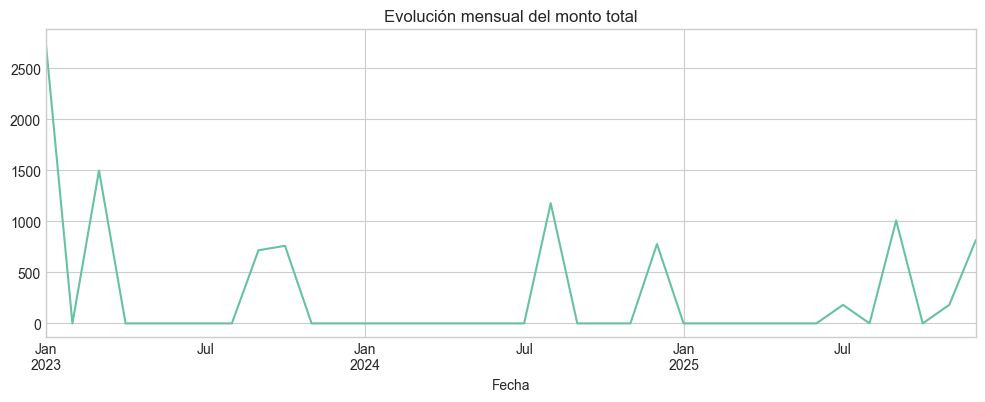

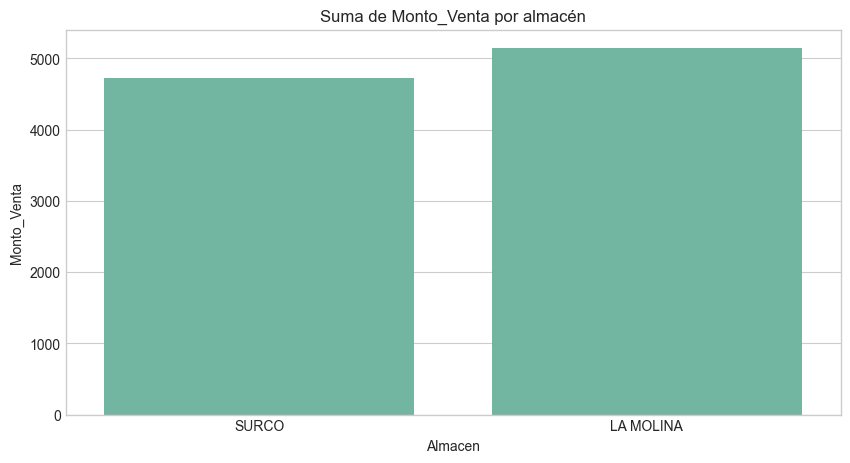

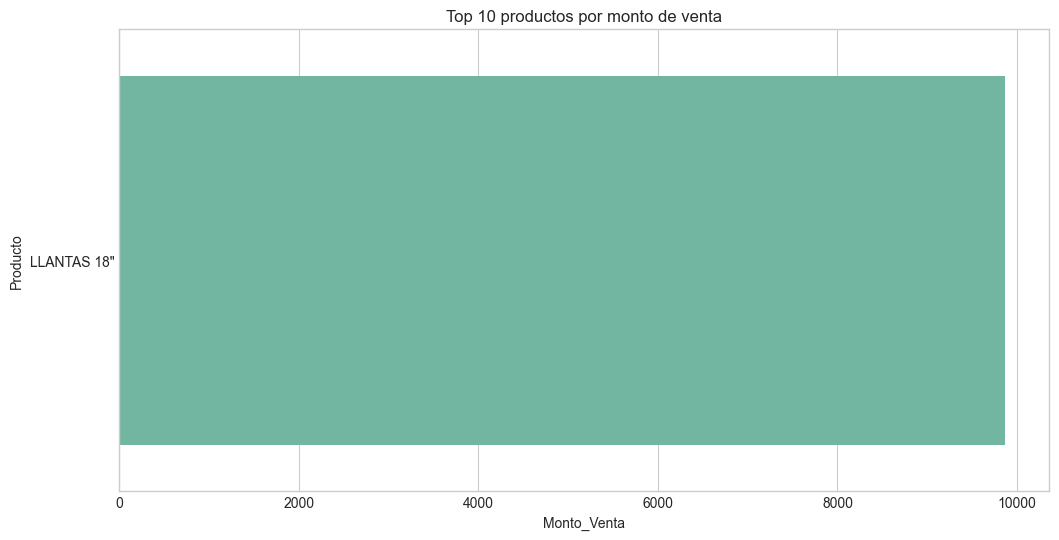

✅ tabla_ventas cargada a SQL Server.

Procesando tabla_compras... (1185 registros originales)
Después de limpieza: 1185 registros

ANÁLISIS EXPLORATORIO: TABLA_COMPRAS
Dimensiones: 1185 filas, 8 columnas

Tipos de datos:
id_compra          int64
Fecha                str
Proveedor            str
Almacen              str
Producto             str
Cantidad           int64
Precio_Compra    float64
Monto            float64
dtype: object

Valores nulos:
id_compra        0
Fecha            0
Proveedor        0
Almacen          0
Producto         0
Cantidad         0
Precio_Compra    0
Monto            0
dtype: int64

Estadísticas descriptivas:


,id_compra,Cantidad,Precio_Compra,Monto
count,1185.000000,1185.000000,1185.000000,1185.000000
mean,593.000000,6.416034,5180.684911,13983.722076
std,342.224342,4.327190,7943.980538,23803.812686
min,1.000000,1.000000,38.640000,74.850000
25%,297.000000,2.000000,87.000000,538.850000
50%,593.000000,5.000000,105.050000,1018.700000
75%,889.000000,10.000000,15580.840000,18744.640000
max,1185.000000,43.000000,24888.360000,104903.550000


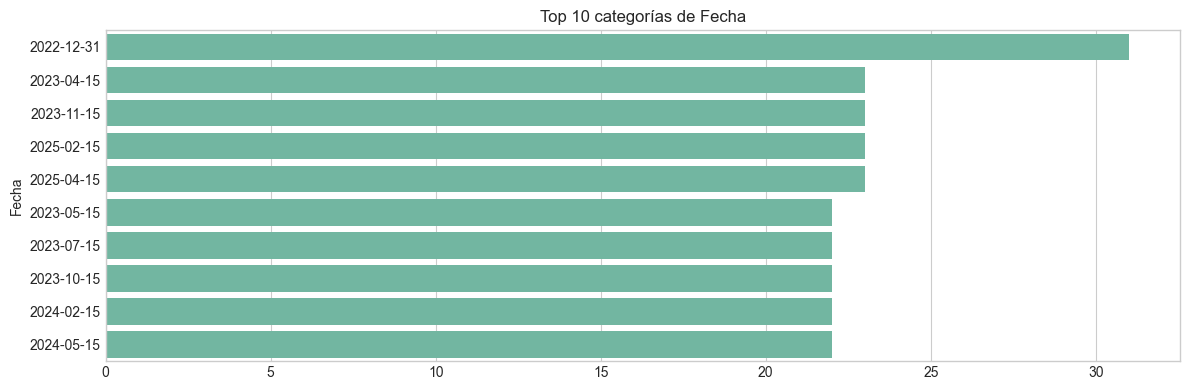

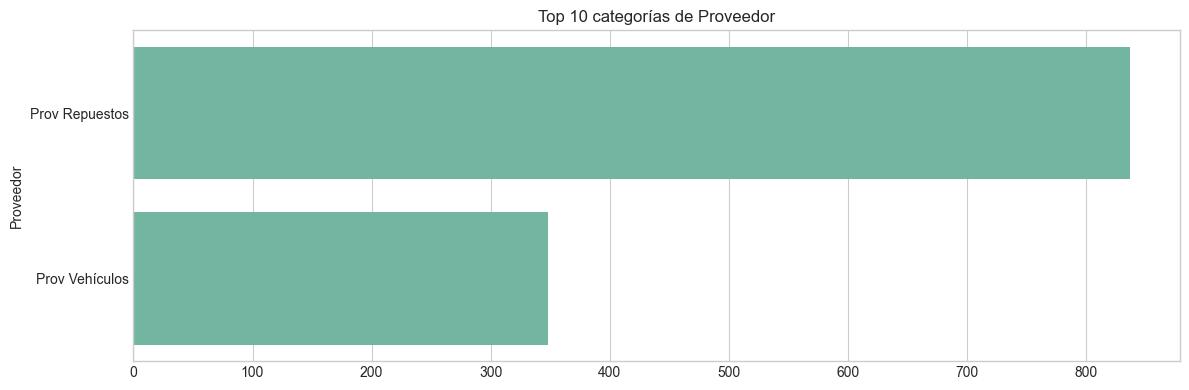

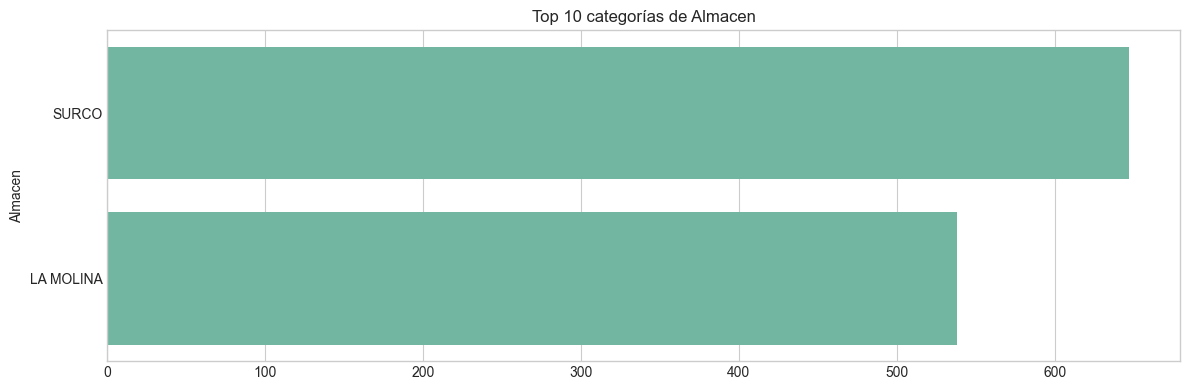

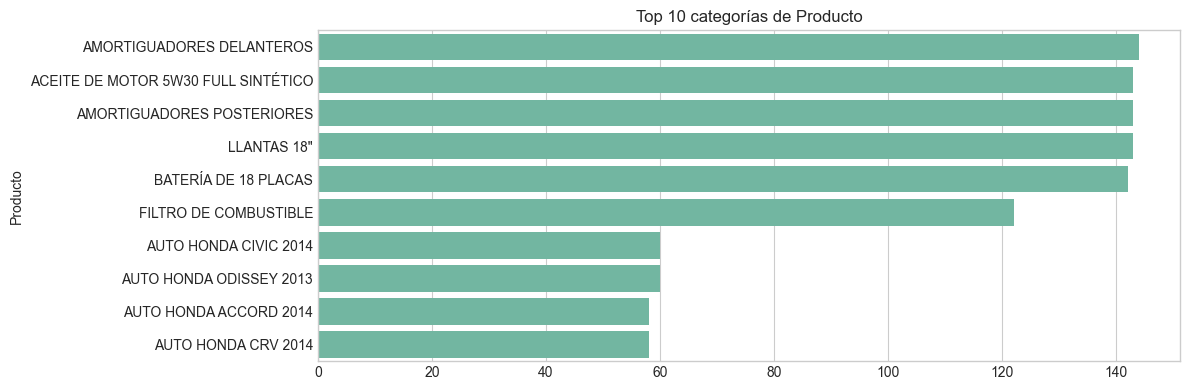

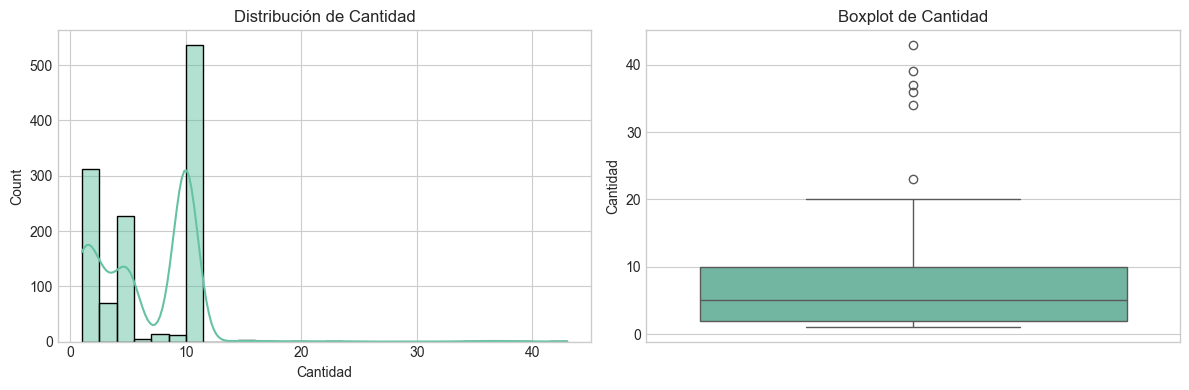

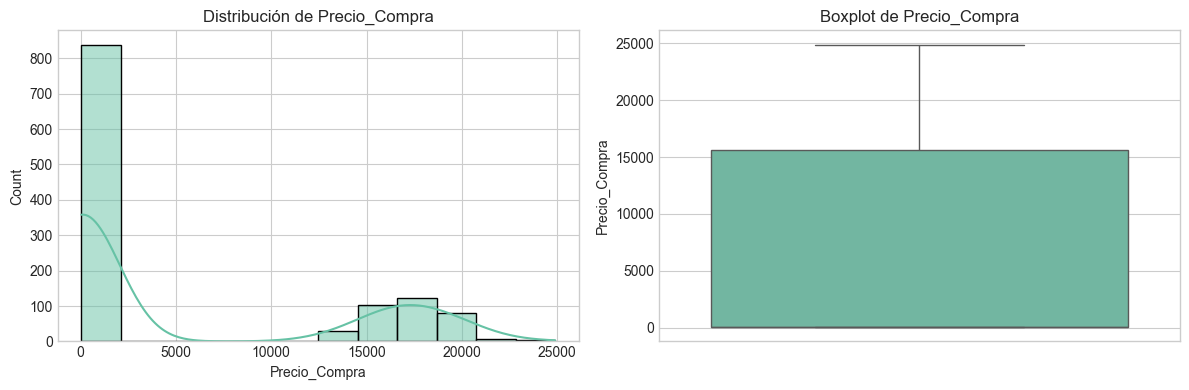

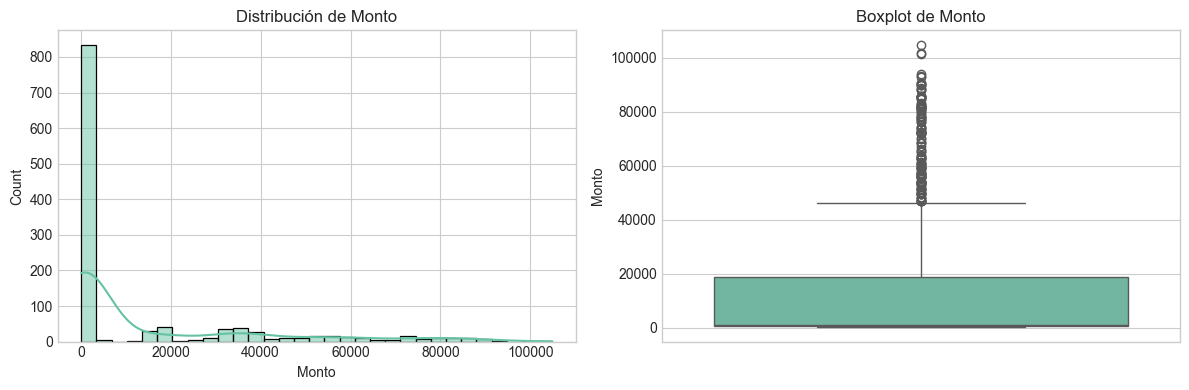

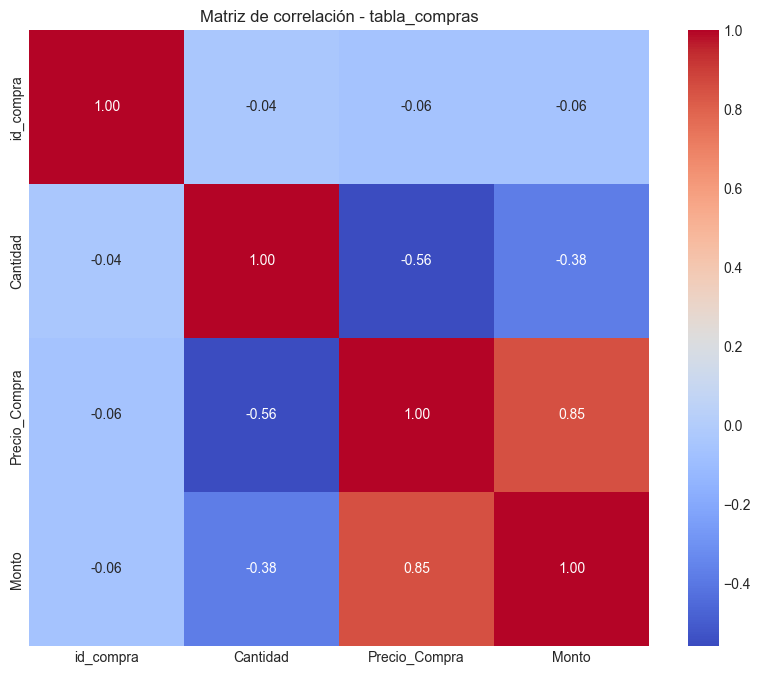

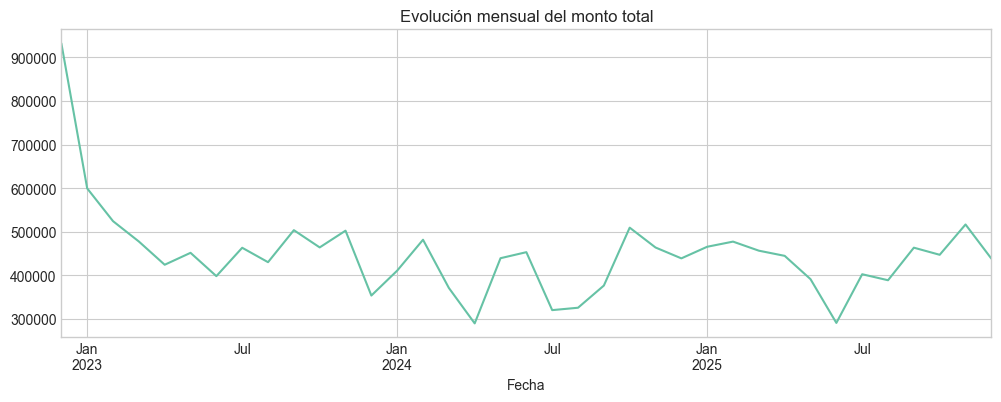

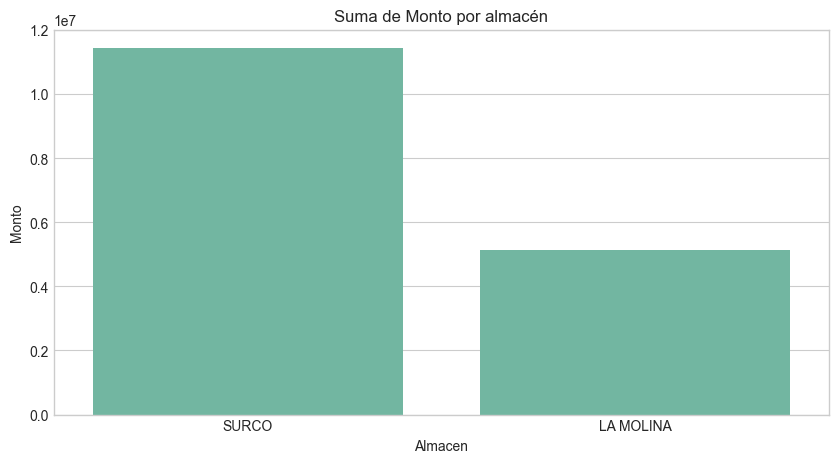

✅ tabla_compras cargada a SQL Server.

Procesando tabla_stock_inventario... (2448 registros originales)
Después de limpieza: 144 registros

ANÁLISIS EXPLORATORIO: TABLA_STOCK_INVENTARIO
Dimensiones: 144 filas, 5 columnas

Tipos de datos:
Fecha               str
Almacen             str
ID_Producto       int64
Producto            str
Cantidad_Stock    int64
dtype: object

Valores nulos:
Fecha             0
Almacen           0
ID_Producto       0
Producto          0
Cantidad_Stock    0
dtype: int64

Estadísticas descriptivas:


,ID_Producto,Cantidad_Stock
count,144.0,144.000000
mean,42.0,0.416667
std,0.0,2.166174
min,42.0,0.000000
25%,42.0,0.000000
50%,42.0,0.000000
75%,42.0,0.000000
max,42.0,24.000000


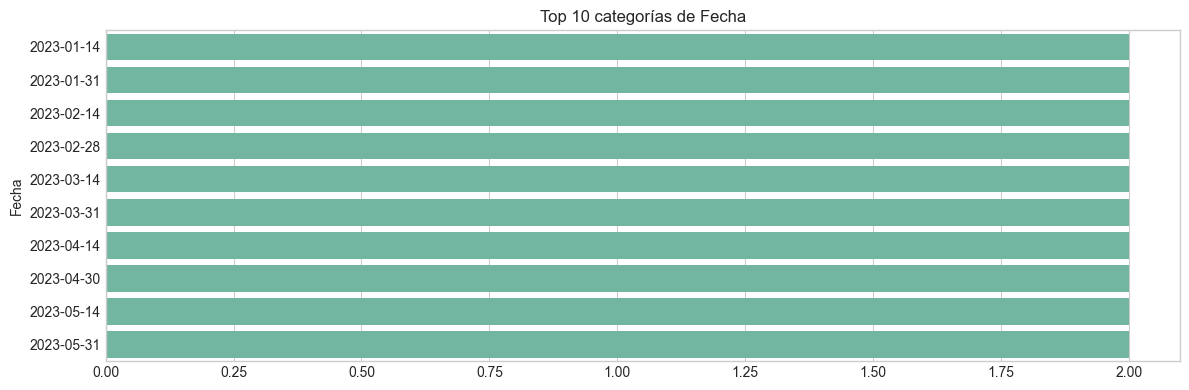

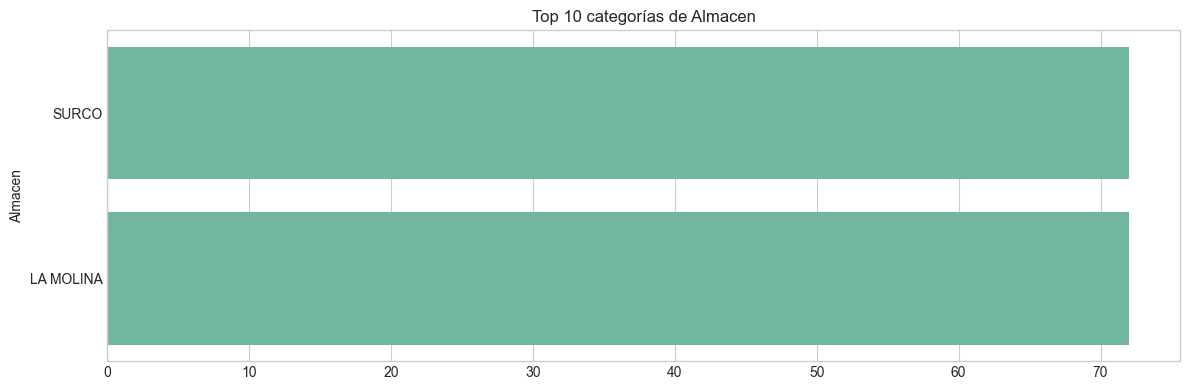

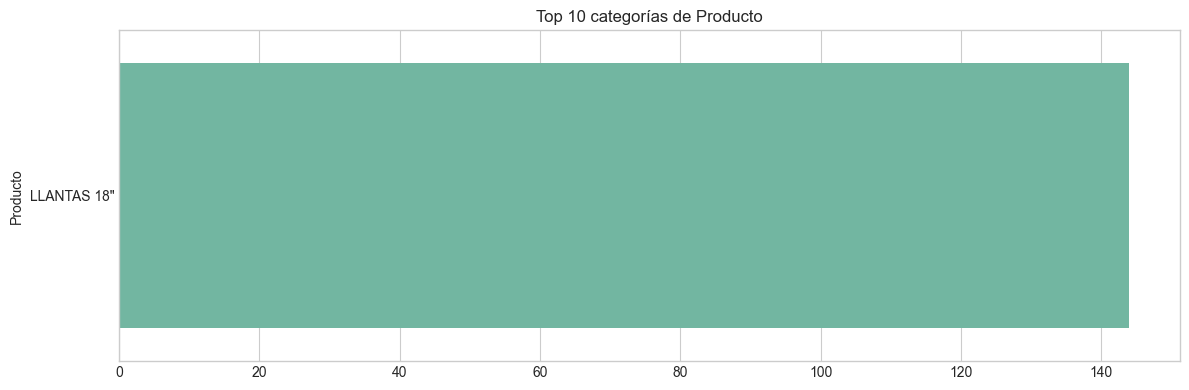

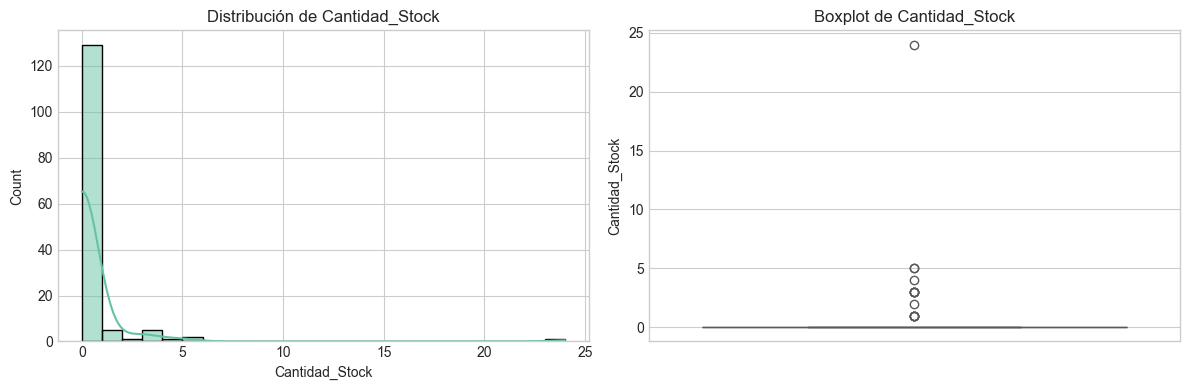

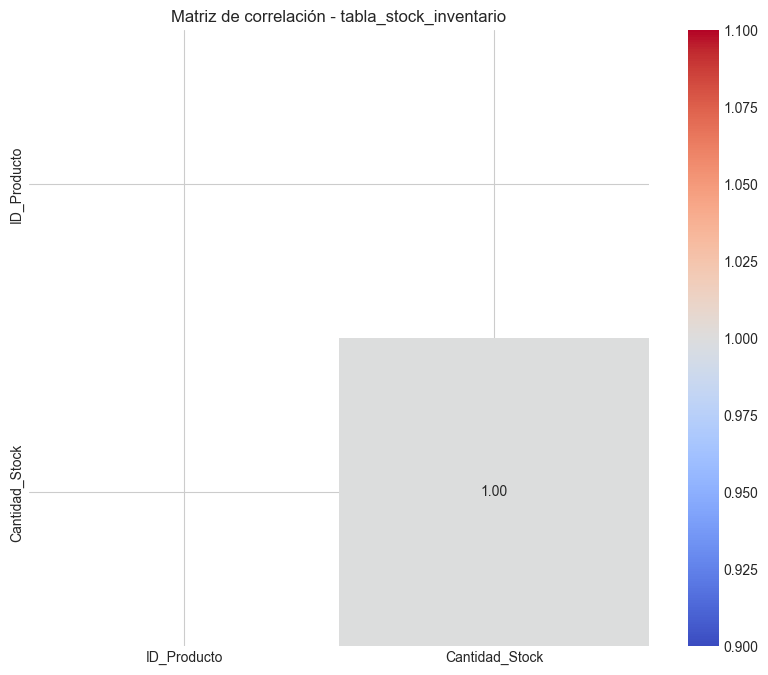

✅ tabla_stock_inventario cargada a SQL Server.
✅ tabla_productos cargada a SQL Server (17 registros).
✅ tabla_almacenes cargada a SQL Server (2 registros).
✅ tabla_clientes cargada a SQL Server (50 registros).

Reporte de limpieza guardado en 'reporte_limpieza.txt'


In [14]:
# Cargar maestras
productos_df, almacenes_df, clientes_df = cargar_maestras()

# Cargar stock para validar ventas
stock_path = os.path.join(DIRECT_BASE, "tabla_stock_inventario.csv")
stock_df = pd.read_csv(stock_path, encoding='utf-8-sig')
# Renombrar columna 'Stock' a 'Cantidad_Stock' si es necesario
if 'Stock' in stock_df.columns and 'Cantidad_Stock' not in stock_df.columns:
    stock_df.rename(columns={'Stock': 'Cantidad_Stock'}, inplace=True)

# Crear base de datos si no existe
from sqlalchemy import create_engine, text
temp_engine = create_engine(f"mssql+pyodbc://@{SERVER}/master?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes")
with temp_engine.connect() as conn:
    result = conn.execute(text(f"SELECT 1 FROM sys.databases WHERE name = '{DATABASE}'"))
    if not result.fetchone():
        conn.execute(text(f"CREATE DATABASE [{DATABASE}]"))
        print(f"Base de datos '{DATABASE}' creada.")
temp_engine.dispose()

engine = create_engine(f"mssql+pyodbc://@{SERVER}/{DATABASE}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes")

# Procesar cada tabla de hechos
for tabla in TABLAS_HECHOS:
    ruta = os.path.join(DIRECT_BASE, f"{tabla}.csv")
    if not os.path.exists(ruta):
        print(f"Archivo no encontrado: {ruta}")
        continue
    
    df_raw = pd.read_csv(ruta, encoding='utf-8-sig')
    print(f"\nProcesando {tabla}... ({len(df_raw)} registros originales)")
    
    df_limpia = limpiar_tabla_hechos(df_raw, tabla, productos_df, 
                                     stock_df if tabla == "tabla_ventas" else None)
    print(f"Después de limpieza: {len(df_limpia)} registros")
    
    # EDA
    eda_completa(df_limpia, tabla)
    
    # Guardar CSV limpio
    df_limpia.to_csv(os.path.join(DIRECT_BASE, f"{tabla}_clean.csv"), index=False, encoding='utf-8-sig')
    
    # Cargar a SQL
    df_limpia.to_sql(tabla, engine, if_exists='replace', index=False)
    print(f"✅ {tabla} cargada a SQL Server.")

# Cargar tablas maestras
for tabla in TABLAS_MAESTRAS:
    ruta = os.path.join(DIRECT_BASE, f"{tabla}.csv")
    df = pd.read_csv(ruta, encoding='utf-8-sig')
    df = df.drop_duplicates()
    df.to_sql(tabla, engine, if_exists='replace', index=False)
    print(f"✅ {tabla} cargada a SQL Server ({len(df)} registros).")

# Guardar reporte de errores
with open(os.path.join(DIRECT_BASE, "reporte_limpieza.txt"), "w", encoding='utf-8') as f:
    f.write("REPORTE DE LIMPIEZA DE DATOS\n")
    f.write("="*40 + "\n")
    for m in reporte_errores:
        f.write(m + "\n")
print("\nReporte de limpieza guardado en 'reporte_limpieza.txt'")